In [1]:
import re 
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer,PorterStemmer
from wordcloud import WordCloud

In [2]:
df = pd.read_csv(r"D:\Innomatics\Git_Uploads\imdb_sentiment_analysis\data\IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
## Positive and Negative is equally distributed

### Text PreProcessing

In [8]:
sw = stopwords.words("english")
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [9]:
## Separating the negative stopwords, as they carry meanung and sentiment

In [10]:
n_sw = ["not","couldn't", 'didn', "didn't", 'doesn', "doesn't", "aren't",'hadn', "hadn't", 'hasn', "hasn't", "don't",'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

In [11]:
p_sw = set(sw).difference(n_sw)

In [12]:
df.sample()

,review,sentiment
30530,"His music, especially what we hear of it here,...",positive


In [13]:
## As we have the HTML tags in the review we have to remove them too

In [14]:
la_st = LancasterStemmer()
po_st = PorterStemmer()

In [15]:
## Text Preprosseing
def text_preprocessing(review):
    # Lower case converstion
    review = review.lower()
    # cleaning html tags
    review = re.sub(r"<.*>"," ",review)
    # Cleaing the puntuation 
    spec_char = r"[^a-z!?\s]"
    review = re.sub(spec_char,"",review)
    # Tokenisation
    review = review.split()
    # Stopwords and Stemming-- Lancaster
    review = [la_st.stem(word) for word in review if word not in p_sw]
    review = " ".join(review)
    return review

In [16]:
df["review"] = df["review"].apply(text_preprocessing)

In [17]:
df["review"]

0        on review ment watch oz episod youl hook right...
1        wond littl produc real real com hom littl thin...
2        thought wond way spend tim hot sum weekend sit...
3        bas ther famy littl boy jak think ther zomby c...
4        pet mat lov tim money vis stun film watch mr m...
                               ...                        
49995    thought movy right good job wasnt cre origin f...
49996    bad plot bad dialog bad act idiot direct annoy...
49997    cathol taught paroch el schools nun taught jes...
49998    im going disagr prevy com sid maltin on second...
49999    on expect star trek movy high art fan expect m...
Name: review, Length: 50000, dtype: str

## Visualization

In [18]:
wc = WordCloud()

<Axes: >

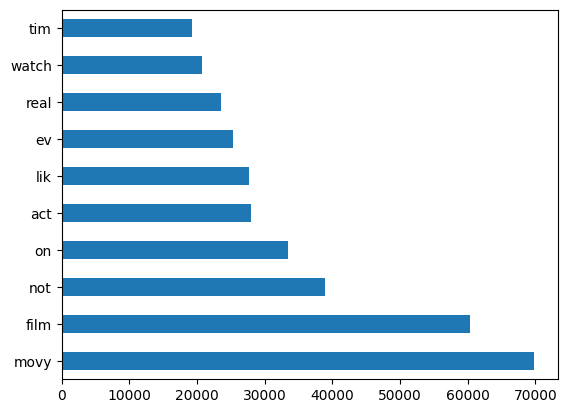

In [19]:
para = " ".join(df["review"])
words = pd.Series(para.split())
words.value_counts().head(10).plot(kind="barh")

([], [])

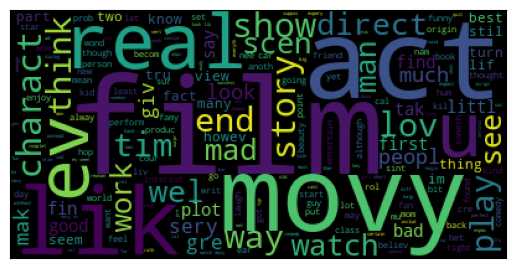

In [20]:
para_wc = wc.generate(para)
plt.imshow(para_wc)
plt.xticks([])
plt.yticks([])

In [21]:
df.sample()

,review,sentiment
34071,act film wel act film say perform slight weak ...,positive


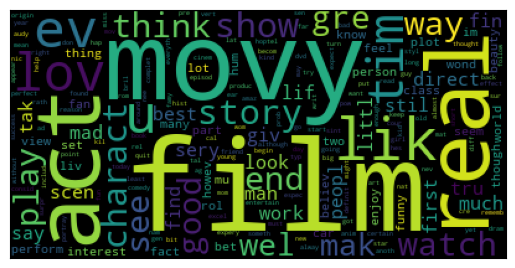

In [22]:
pos_para = " ".join(df[df["sentiment"]=="positive"]["review"])
pos_wc = wc.generate(pos_para)
plt.imshow(pos_wc)
plt.xticks([])
plt.yticks([])
plt.show()

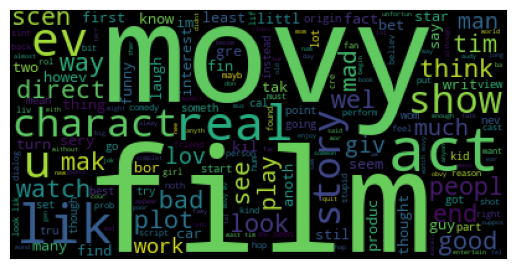

In [23]:
neg_para = " ".join(df[df["sentiment"]=="negative"]["review"])
neg_wc = wc.generate(neg_para)
plt.imshow(neg_wc)
plt.xticks([])
plt.yticks([])
plt.show()

## Vetorization

### 1.Bag of Words (BOW)

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
cv = CountVectorizer(max_features=1000)

In [26]:
X = cv.fit_transform(df["review"]).toarray()

In [27]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(50000, 1000))

In [28]:
cols = cv.get_feature_names_out()

In [29]:
X = pd.DataFrame(X,columns=cols)
X

,abl,absolv,acc,acceiv,accid,achiev,across,act,actress,ad,...,ye,year,yet,yo,york,you,youl,young,youv,zomby
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49996,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
49997,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
49998,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
y = df["sentiment"]

### Data Split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X.values,y,train_size=0.8,random_state=42)

In [33]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((40000, 1000), (10000, 1000), (40000,), (10000,))

### Min Max Scaler

In [34]:
from sklearn.preprocessing import MinMaxScaler

In [35]:
sc = MinMaxScaler()

In [36]:
X_train = sc.fit_transform(X_train)

In [37]:
X_test = sc.transform(X_test)

### Model Building

In [38]:
from sklearn.naive_bayes import GaussianNB

In [39]:
nb_model = GaussianNB()

In [40]:
nb_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Prediction

In [41]:
y_pred = nb_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

In [43]:
bow_test_accuracy = accuracy_score(y_test,y_pred)
bow_test_accuracy

0.7692

In [44]:
from sklearn.metrics import confusion_matrix,classification_report

In [45]:
print(classification_report(y_test,y_pred,target_names=["Negative","Positive"]))

              precision    recall  f1-score   support

    Negative       0.75      0.80      0.77      4961
    Positive       0.79      0.74      0.76      5039

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



In [54]:
## Confusion matrix
cm_bow = confusion_matrix(y_test,y_pred)
cm_bow


array([[3957, 1004],
       [1304, 3735]])

In [50]:
from mlxtend.plotting import plot_confusion_matrix

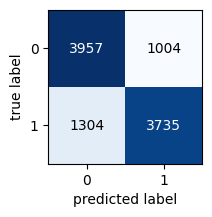

In [55]:
fig,ax = plot_confusion_matrix(cm_bow,figsize=(3,2))

In [53]:
## Accuracy is not good.

## TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [59]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2))

In [60]:
X2 = tfidf.fit_transform(df["review"]).toarray()

In [61]:
X2

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50000, 1000))

In [65]:
cols2 = tfidf.get_feature_names_out()
cols2

array(['abl', 'absolv', 'acc', 'acceiv', 'across', 'act', 'act movy',
       'actress', 'ad', 'adapt', 'admit', 'adult', 'adv', 'ag', 'ago',
       'agr', 'air', 'al', 'allow', 'almost', 'alon', 'along', 'already',
       'also', 'although', 'alway', 'aly', 'am', 'amaz', 'americ',
       'among', 'amount', 'amus', 'an', 'angel', 'anim', 'annoy', 'anoth',
       'answ', 'anyon', 'anyth', 'anyway', 'ap', 'apart', 'app', 'appear',
       'apprecy', 'ar', 'around', 'art', 'ask', 'aspect', 'at', 'atmosph',
       'attack', 'attempt', 'attract', 'audy', 'auth', 'av', 'avoid',
       'aw', 'award', 'away', 'baby', 'back', 'background', 'bad',
       'bad act', 'bad movy', 'bal', 'band', 'bar', 'bas', 'battl',
       'beat', 'beauty', 'becam', 'becom', 'begin', 'behind', 'believ',
       'best', 'bet', 'beyond', 'big', 'bil', 'bit', 'black', 'blood',
       'body', 'book', 'bor', 'both', 'bought', 'box', 'boy', 'brain',
       'break', 'bril', 'bring', 'brit', 'broth', 'brought', 'budget',
   

In [66]:
X2 = pd.DataFrame(X2,columns=cols2)
X2

,abl,absolv,acc,acceiv,across,act,act movy,actress,ad,adapt,...,year,year ago,year old,yet,yo,york,youl,young,youv,zomby
0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.114076,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.316779
4,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49996,0.0,0.0,0.0,0.0,0.00000,0.097837,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49997,0.0,0.0,0.0,0.0,0.00000,0.063974,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49998,0.0,0.0,0.0,0.0,0.14441,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000


In [62]:
y2 = df["sentiment"]

In [67]:
X2_train,X2_test,y2_train,y2_test = train_test_split(X2.values,y2,random_state=42)

In [68]:
X2_train.shape,X2_test.shape,y2_train.shape,y2_test.shape

((37500, 1000), (12500, 1000), (37500,), (12500,))

### Scaling

In [69]:
sc2 = MinMaxScaler()

In [70]:
X2_train = sc2.fit_transform(X2_train)
X2_test = sc2.transform(X2_test)

### Model Building

In [71]:
nb_model_tfidf = GaussianNB()

In [72]:
nb_model_tfidf.fit(X2_train,y2_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [73]:
y2_pred = nb_model_tfidf.predict(X2_test)

In [74]:
tfidf_accuracy = accuracy_score(y2_test,y2_pred)
tfidf_accuracy

0.7808

In [75]:
print(classification_report(y2_test,y2_pred,target_names=["Negative","Positive"]))

              precision    recall  f1-score   support

    Negative       0.79      0.75      0.77      6157
    Positive       0.77      0.81      0.79      6343

    accuracy                           0.78     12500
   macro avg       0.78      0.78      0.78     12500
weighted avg       0.78      0.78      0.78     12500



In [76]:
cm_tfidf = confusion_matrix(y2_test,y2_pred)
cm_tfidf

array([[4645, 1512],
       [1228, 5115]])

(<Figure size 300x200 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

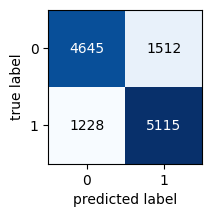

In [78]:
plot_confusion_matrix(cm_tfidf,figsize=(3,2))

In [79]:
print(f"BOW accuracy: {bow_test_accuracy}")
print(f"Tf-Idf accuracy : {tfidf_accuracy}")

BOW accuracy: 0.7692
Tf-Idf accuracy : 0.7808


In [80]:
## Real Time prediciton

In [105]:
def realtimepred_tfidf(review):
    review = text_preprocessing(review)
    review = tfidf.transform([review]).toarray()
    review = sc2.transform(review)
    pred = nb_model_tfidf.predict(review)
    classes = ["Neagative","Positive"]
    return pred[0]

In [106]:
def realtimepred_bow(review):
    review = text_preprocessing(review)
    review = cv.transform([review]).toarray()
    review = sc.transform(review)
    pred = nb_model.predict(review)
    classes = ["Negative","Positive"]
    return pred[0]

In [120]:
review = "Movie is ok ok. really liked the plot and cinematography. But hate the ending and plot aromor at times"

In [121]:
realtimepred_bow(review)

np.str_('negative')

In [122]:
realtimepred_tfidf(review)

np.str_('negative')

## Comparision of BOW and Tf-IDF

In [118]:
comparision = pd.DataFrame({
    "Model" : ["BOW","TF-IDF"],
    "Accuracy" : [bow_test_accuracy,tfidf_accuracy]
})

In [119]:
comparision

,Model,Accuracy
0,BOW,0.7692
1,TF-IDF,0.7808


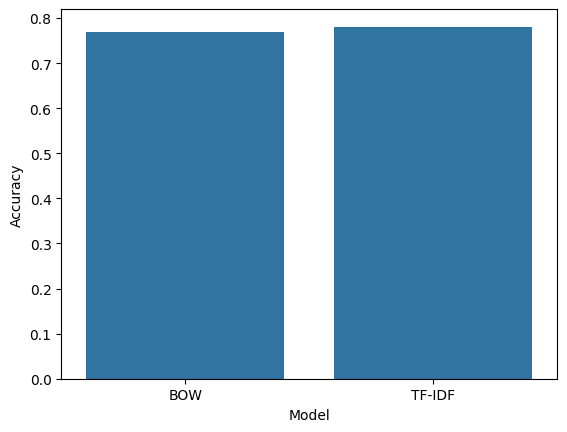

In [131]:
sns.barplot(comparision,x="Model",y="Accuracy")
plt.show()

## Save the model

In [123]:
nb_model.cv = cv
nb_model.sc = sc

In [124]:
import joblib

In [129]:
joblib.dump(nb_model,"Movie_review_sentiment_BOW.pkl")

['Movie_review_sentiment_BOW.pkl']

In [127]:
nb_model_tfidf.tfidf=tfidf
nb_model_tfidf.sc = sc2

In [130]:
joblib.dump(nb_model_tfidf,"Movie_review_sentiment_TF-IDF.pkl")

['Movie_review_sentiment_TF-IDF.pkl']